--- Model Evaluation ---
R-squared Score: 0.3122
RMSE: 4.9899



/var/folders/xg/slbv315n7nsgjg7ncb501lxc0000gn/T/ipykernel_1950/608271167.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


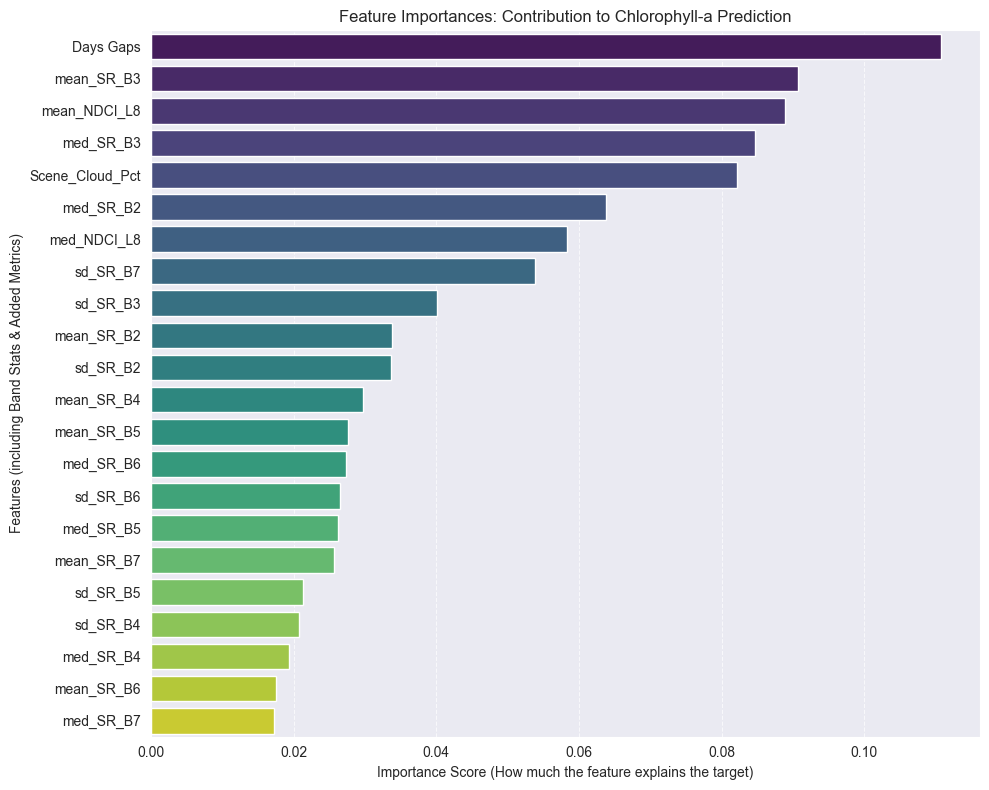

--- Feature Importance Ranking ---
        Feature  Importance
      Days Gaps    0.110667
     mean_SR_B3    0.090676
   mean_NDCI_L8    0.088875
      med_SR_B3    0.084662
Scene_Cloud_Pct    0.082183
      med_SR_B2    0.063797
    med_NDCI_L8    0.058333
       sd_SR_B7    0.053796
       sd_SR_B3    0.040169
     mean_SR_B2    0.033869
       sd_SR_B2    0.033649
     mean_SR_B4    0.029718
     mean_SR_B5    0.027703
      med_SR_B6    0.027323
       sd_SR_B6    0.026462
      med_SR_B5    0.026171
     mean_SR_B7    0.025678
       sd_SR_B5    0.021315
       sd_SR_B4    0.020805
      med_SR_B4    0.019310
     mean_SR_B6    0.017523
      med_SR_B7    0.017315


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

# 2. Define target and feature columns
target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:29].tolist()


additional_features = ['mean_NDCI_L8', 'med_NDCI_L8', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features


data = df[[target_col] + feature_cols].dropna()

X = data[feature_cols]
y = data[target_col]

# 4. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Initialize and train the Random Forest Regressor
# n_estimators=100 creates 100 decision trees
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions and Evaluate
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}\n")

# 7. Extract and Visualize Feature Importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the graph
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances: Contribution to Chlorophyll-a Prediction')
plt.xlabel('Importance Score (How much the feature explains the target)')
plt.ylabel('Features (including Band Stats & Added Metrics)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the importance values
print("--- Feature Importance Ranking ---")
print(feature_importance_df.to_string(index=False))